In [89]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

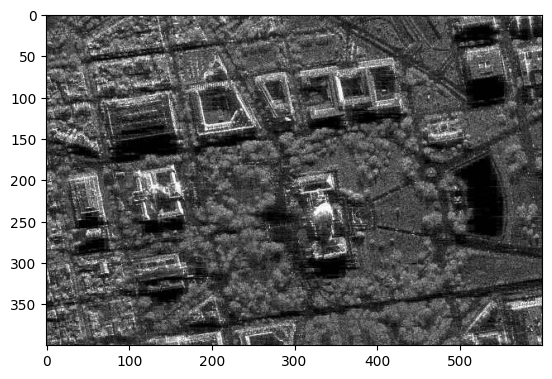

In [90]:
#task1
image = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')

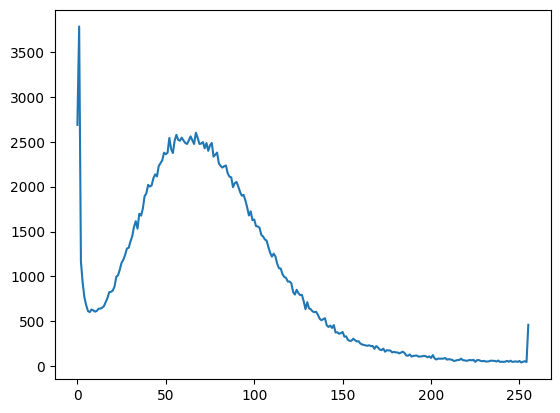

In [91]:
#task2
histSize = 256
histRange = (0, 256)
accumulate = False

hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate)

plt.plot(hist)

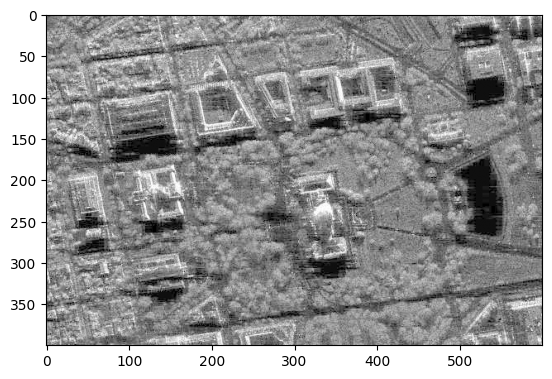

In [92]:
#task3 gamma<1
import copy

image2 = copy.deepcopy(image).astype(np.float32)
gamma = 0.5
r_max = image2.max()
h, w = image2.shape
for y in range(h):
    for x in range(w):
        r_old = image2[y, x]
        image2[y, x] = ((r_old/r_max) ** gamma) * r_max
image2 = np.clip(image2, 0, 255)
image2 = image2.astype(np.uint8)
plt.imshow(image2, cmap='gray')

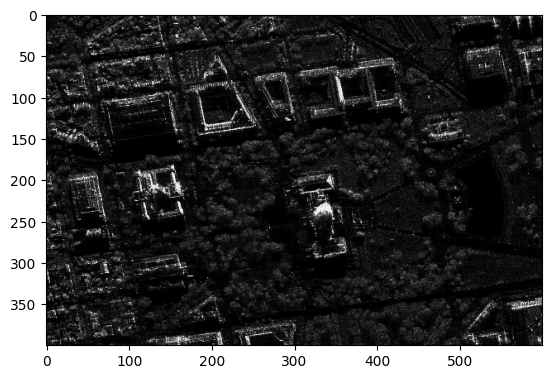

In [93]:
#task3 gamma>1
import copy

image3 = copy.deepcopy(image).astype(np.float32)
gamma = 2.25
r_max = image3.max()
h, w = image2.shape
for y in range(h):
    for x in range(w):
        r_old = image3[y, x]
        image3[y, x] = ((r_old/r_max) ** gamma) * r_max
image3 = np.clip(image3, 0, 255)
image3 = image3.astype(np.uint8)
plt.imshow(image3, cmap='gray')

In [94]:
#task4 gamma<1
from skimage.metrics import structural_similarity, mean_squared_error

ssim, _ = structural_similarity(image, image2, full=True)
print("SSIM: {}".format(ssim))
mse = mean_squared_error(image, image2)
print("MSE: {}".format(mse))

SSIM: 0.7875008686792753
MSE: 3250.429145833333


In [95]:
#task4 gamma>1
from skimage.metrics import structural_similarity, mean_squared_error

ssim, _ = structural_similarity(image, image3, full=True)
print("SSIM: {}".format(ssim))
mse = mean_squared_error(image, image3)
print("MSE: {}".format(mse))

SSIM: 0.4153243047248213
MSE: 3013.4335


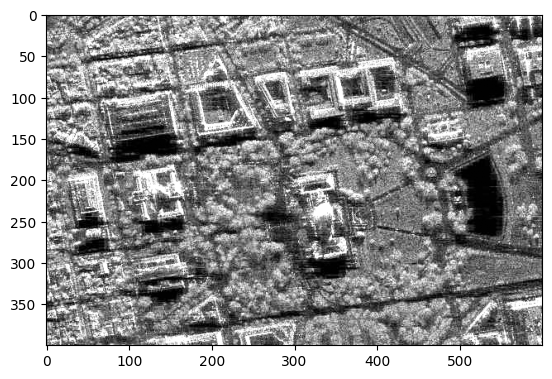

In [ ]:
#task5
image4 = copy.deepcopy(image).astype(np.float32)

eq_gray = cv2.equalizeHist(image)

mean1 = image.mean()
std1 = image.std()
mean2 = eq_gray.mean()
std2 = eq_gray.std()

h, w = image.shape
for y in range(h):
    for x in range(w):
        image4[y, x] = mean2 + (image4[y, x] - mean1) * (std2 / std1)
image4 = np.clip(image4, 0, 255)
image4 = image4.astype(np.uint8)
plt.imshow(image4, cmap='gray')

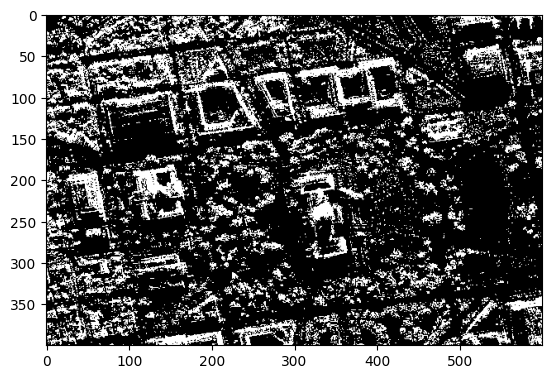

In [102]:
#task6 100
_,thresh1 = cv2.threshold(image,100,255,cv2.THRESH_BINARY)

plt.imshow(thresh1, cmap='gray')

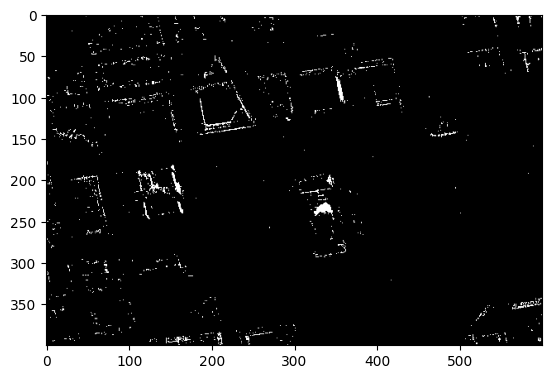

In [104]:
#task6 200
_,thresh3 = cv2.threshold(image,200,255,cv2.THRESH_BINARY)

plt.imshow(thresh3, cmap='gray')

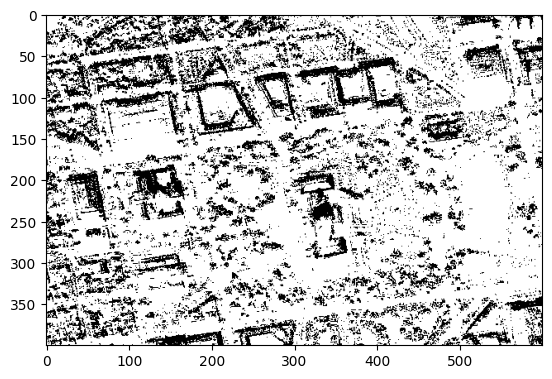

In [ ]:
#task6 100 inv
_,thresh1 = cv2.threshold(image,100,255,cv2.THRESH_BINARY_INV)

plt.imshow(thresh1, cmap='gray')

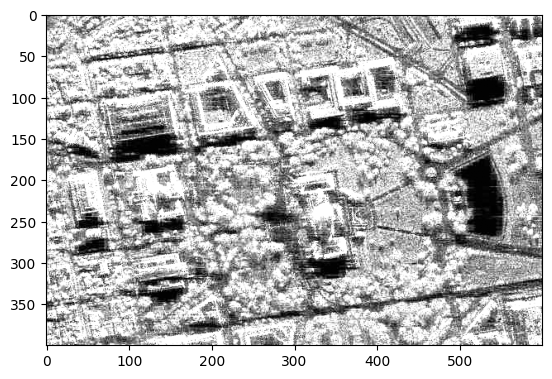

In [106]:
#task6 100 trunc
_,thresh1 = cv2.threshold(image,100,255,cv2.THRESH_TRUNC)

plt.imshow(thresh1, cmap='gray')